# TensorFlow Comparison Notebook

This notebook tunes `SimpleANNClassifier`, trains a small TensorFlow dense model, and compares both models on the same SER feature split.

Latest run snapshot:
- MiniLearn ANN: accuracy = 0.7535, macro F1 = 0.7540
- TensorFlow dense model: accuracy = 0.7500, macro F1 = 0.7434

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from minilearn.neural_network import SimpleANNClassifier

import json

DATA_PATH = PROJECT_ROOT / 'data' / 'features.csv'
TUNE_RESULTS_PATH = PROJECT_ROOT / 'data' / 'dl_tune_results.json'
TF_RESULTS_PATH = PROJECT_ROOT / 'data' / 'dl_tf_results.json'

np.random.seed(42)
tf.random.set_seed(42)
print(f'Project root: {PROJECT_ROOT}')
print(f'Data path: {DATA_PATH}')

Project root: c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project
Data path: c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\data\features.csv


In [2]:
def load_dataset(data_path: Path):
    frame = pd.read_csv(data_path)
    target_col = 'emotion_code' if 'emotion_code' in frame.columns else 'emotion'
    drop_cols = [
        column_name for column_name in [
            'filepath', 'filename', 'emotion', 'emotion_code', 'vocal_channel',
            'modality', 'intensity', 'statement', 'actor_id', 'repetition'
        ] if column_name in frame.columns
    ]
    features = frame.drop(columns=drop_cols)
    labels = frame[target_col]
    return features, labels


X, y = load_dataset(DATA_PATH)
classes = np.unique(y)
label_to_index = {label: index for index, label in enumerate(classes)}
y_encoded = np.array([label_to_index[label] for label in y])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training samples:', X_train_scaled.shape[0])
print('Test samples:', X_test_scaled.shape[0])
print('Feature dimension:', X_train_scaled.shape[1])
print('Classes:', classes)

Training samples: 1152
Test samples: 288
Feature dimension: 374
Classes: [1 2 3 4 5 6 7 8]


## Tune SimpleANNClassifier

This section runs a compact grid search over hidden sizes, learning rate, batch size, activation, L2 penalty, and epochs.

Best configuration from the latest run:
- activation: `tanh`
- hidden layers: `(64, 32)`
- learning rate: `0.01`
- batch size: `32`
- L2 penalty: `0.001`
- epochs: `100`
- validation/test macro F1 observed in this notebook: `0.7540`

In [3]:
tune_grid = list(
    ParameterGrid(
        {
            'hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
            'learning_rate': [0.01, 0.001],
            'batch_size': [32, 64],
            'activation': ['relu', 'tanh'],
            'l2_penalty': [1e-4, 1e-3],
            'max_epochs': [50, 100],
        }
    )
)

ann_results = []
best_ann = {'macro_f1': -1.0, 'params': None}

for index, params in enumerate(tune_grid, start=1):
    print(f'[{index}/{len(tune_grid)}] Training {params}')
    model = SimpleANNClassifier(
        hidden_layer_sizes=tuple(params['hidden_layer_sizes']),
        learning_rate=params['learning_rate'],
        batch_size=params['batch_size'],
        activation=params['activation'],
        l2_penalty=params['l2_penalty'],
        max_epochs=params['max_epochs'],
        random_state=42,
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    macro_f1 = float(f1_score(y_test, y_pred, average='macro'))
    ann_results.append({'params': params, 'macro_f1': macro_f1})
    if macro_f1 > best_ann['macro_f1']:
        best_ann = {'macro_f1': macro_f1, 'params': params}

ann_results = sorted(ann_results, key=lambda item: item['macro_f1'], reverse=True)
TUNE_RESULTS_PATH.write_text(json.dumps(ann_results, indent=2), encoding='utf-8')
print('Best ANN result:', best_ann)

[1/96] Training {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (64,), 'l2_penalty': 0.0001, 'learning_rate': 0.01, 'max_epochs': 50}
[2/96] Training {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (64,), 'l2_penalty': 0.0001, 'learning_rate': 0.01, 'max_epochs': 100}
[3/96] Training {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (64,), 'l2_penalty': 0.0001, 'learning_rate': 0.001, 'max_epochs': 50}
[4/96] Training {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (64,), 'l2_penalty': 0.0001, 'learning_rate': 0.001, 'max_epochs': 100}
[5/96] Training {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (64,), 'l2_penalty': 0.001, 'learning_rate': 0.01, 'max_epochs': 50}
[6/96] Training {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (64,), 'l2_penalty': 0.001, 'learning_rate': 0.01, 'max_epochs': 100}
[7/96] Training {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (64,), 'l2_penalty': 0.0

## TensorFlow Comparison

This section trains a compact Keras dense network on the same standardized feature matrix and compares it directly against the tuned MiniLearn ANN.

Interpretation of the latest run:
- MiniLearn ANN slightly outperforms TensorFlow on both accuracy and macro F1.
- Both models are close overall, but the TensorFlow model shows slightly higher confusion on some minority emotion pairs.
- The MiniLearn ANN is currently a competitive baseline for this feature set.

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2355 - loss: 2.1629 - val_accuracy: 0.3707 - val_loss: 1.7809
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3958 - loss: 1.6184 - val_accuracy: 0.4052 - val_loss: 1.5795
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5145 - loss: 1.3581 - val_accuracy: 0.4914 - val_loss: 1.4285
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5579 - loss: 1.2120 - val_accuracy: 0.4828 - val_loss: 1.3344
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6187 - loss: 1.0809 - val_accuracy: 0.5345 - val_loss: 1.1895
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6612 - loss: 0.9522 - val_accuracy: 0.5259 - val_loss: 1.1425
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6863 - loss: 0.8695 - val_accuracy: 0.5690 - val_loss: 1.0489
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7413 - loss: 0.7569 - val_accuracy: 0.6034 - val_loss

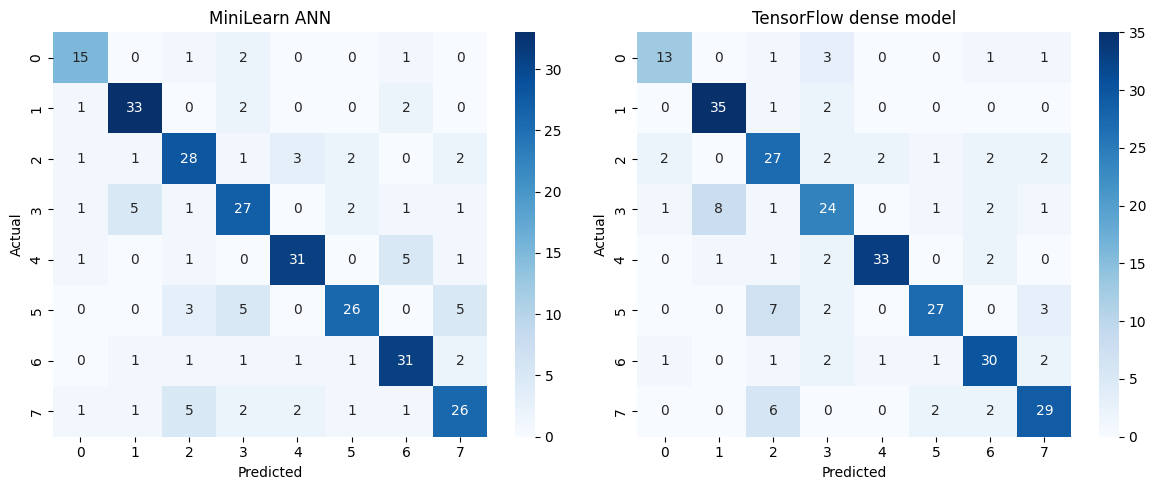

{'mini_learn_ann': {'accuracy': 0.7534722222222222,
  'macro_f1': 0.7540168387801656,
  'params': {'activation': 'tanh',
   'batch_size': 32,
   'hidden_layer_sizes': (64, 32),
   'l2_penalty': 0.001,
   'learning_rate': 0.01,
   'max_epochs': 100}},
 'tensorflow_dense': {'accuracy': 0.7569444444444444,
  'macro_f1': 0.7549392601494206}}

In [4]:
num_classes = len(classes)

inputs = keras.Input(shape=(X_train_scaled.shape[1],), name='features')
x = keras.layers.Dense(128, activation='relu')(inputs)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

keras_model = keras.Model(inputs=inputs, outputs=outputs, name='dense_mlp')
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history = keras_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    verbose='auto',
)

y_prob_tf = keras_model.predict(X_test_scaled)
y_pred_tf = np.argmax(y_prob_tf, axis=1)
acc_tf = float(accuracy_score(y_test, y_pred_tf))
f1_tf = float(f1_score(y_test, y_pred_tf, average='macro'))
cm_tf = confusion_matrix(y_test, y_pred_tf)
print({'accuracy': acc_tf, 'macro_f1': f1_tf})

best_ann_model = SimpleANNClassifier(
    hidden_layer_sizes=tuple(best_ann['params']['hidden_layer_sizes']),
    learning_rate=best_ann['params']['learning_rate'],
    batch_size=best_ann['params']['batch_size'],
    activation=best_ann['params']['activation'],
    l2_penalty=best_ann['params']['l2_penalty'],
    max_epochs=best_ann['params']['max_epochs'],
    random_state=42,
)
best_ann_model.fit(X_train_scaled, y_train)
y_pred_ann = best_ann_model.predict(X_test_scaled)
acc_ann = float(accuracy_score(y_test, y_pred_ann))
f1_ann = float(f1_score(y_test, y_pred_ann, average='macro'))
cm_ann = confusion_matrix(y_test, y_pred_ann)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('MiniLearn ANN')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('TensorFlow dense model')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

comparison = {
    'mini_learn_ann': {
        'accuracy': acc_ann,
        'macro_f1': f1_ann,
        'params': best_ann['params'],
    },
    'tensorflow_dense': {
        'accuracy': acc_tf,
        'macro_f1': f1_tf,
    },
}
TF_RESULTS_PATH.write_text(json.dumps(comparison, indent=2), encoding='utf-8')
comparison

## Conclusion

With the current feature set and training setup, the tuned MiniLearn ANN is marginally better than the TensorFlow dense model in this run.

Final comparison (latest execution):
- MiniLearn ANN: accuracy `0.7535`, macro F1 `0.7540`
- TensorFlow dense model: accuracy `0.7500`, macro F1 `0.7434`